<a href="https://www.kaggle.com/code/hsintlintun/analysis-1-monthly-cancel-rate?scriptVersionId=331844997" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames: 
        print(os.path.join(dirname,filename))

/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv


In [2]:
import pandas as pd 
df = pd.read_csv('/kaggle/input/datasets/jessemostipak/hotel-booking-demand/hotel_bookings.csv')
df. head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
#1. How much total bookings?
print(f"total bookings:{len(df)}")

#2. Cancel Rate?
cancel_rate = df ['is_canceled']. mean ()*100
print (f"Overall cancel rate:{cancel_rate:2f}%")

#3. Which kind of hotels?
print ("\nHotel type:")
print (df['hotel'].value_counts())

total bookings:119390
Overall cancel rate:37.041628%

Hotel type:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


In [4]:
monthly_result = df.groupby('arrival_date_month').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum')
).reset_index()

monthly_result['cancel_rate_pct'] = round(monthly_result['canceled_bookings'] * 100.0 / monthly_result['total_bookings'], 2)
monthly_result = monthly_result.sort_values('cancel_rate_pct', ascending=False)

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_result['arrival_date_month'] = pd.Categorical(monthly_result['arrival_date_month'], categories=month_order, ordered=True)
monthly_result = monthly_result.sort_values('arrival_date_month')

print("Cancel Rate by Month - Highest to Lowest")
print(monthly_result.sort_values('cancel_rate_pct', ascending=False))

Cancel Rate by Month - Highest to Lowest
   arrival_date_month  total_bookings  canceled_bookings  cancel_rate_pct
6                June           10939               4535            41.46
0               April           11089               4524            40.80
8                 May           11791               4677            39.67
11          September           10508               4116            39.17
10            October           11160               4246            38.05
1              August           13877               5239            37.75
5                July           12661               4742            37.45
2            December            6780               2371            34.97
3            February            8068               2696            33.42
7               March            9794               3149            32.15
9            November            6794               2122            31.23
4             January            5929               1807            30.

/tmp/ipykernel_16/3303886567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='arrival_date_month', y='cancel_rate_pct', palette='Reds_r')


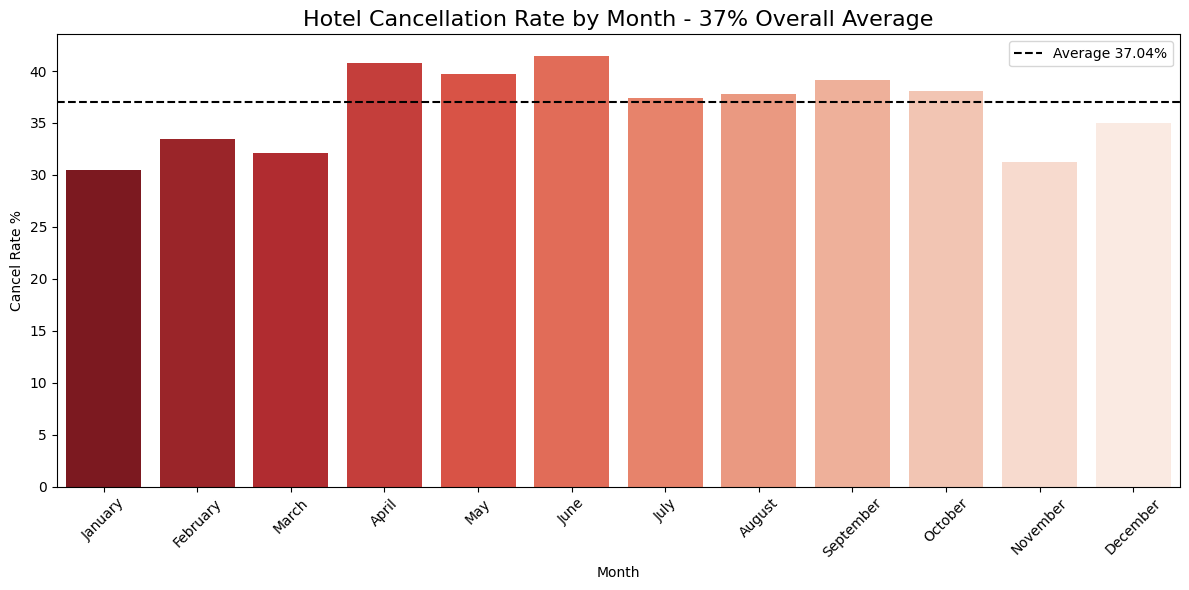

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
#list month order
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
plot_data = monthly_result.set_index('arrival_date_month').loc[month_order].reset_index()

sns.barplot(data=plot_data, x='arrival_date_month', y='cancel_rate_pct', palette='Reds_r')
plt.title('Hotel Cancellation Rate by Month - 37% Overall Average', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Cancel Rate %')
plt.axhline(y=37.04, color='black', linestyle='--', label='Average 37.04%')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Key Finding 1: Seasonality Drives Cancellations
- **June has the highest cancel rate at 41.46%**, followed by April at 40.80%
- **August has the most total cancellations: 5,239 bookings** due to high volume
- Overall cancel rate is 37.04% across 119k bookings

### Business Impact for Online Travel Agencies:
Summer and spring months show 40%+ cancel rates. This directly impacts hotel partner revenue and OTA platform commissions.

### Recommendation:
1. Implement "Non-refundable rate" discount for June-August bookings to lock in customers
2. Send reminder emails 7 days before arrival for high-risk months
3. Potential revenue recovery: If we reduce June cancels by 5%, that's 547 saved bookings

In [6]:
### Analysis 2: Lead Time vs Cancellation Rate 

# lead_time 
bins = [0,7,30,90,180,1000]
labels = ['0-7 days','8-30 days','31-90days', '91-180 days', '180+ days']
df['lead_time_bucket'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

#calculate cancel rate 
leadtime_result = df.groupby('lead_time_bucket', observed=True).agg(total_bookings=('is_canceled', 'count'),canceled_bookings=('is_canceled', 'sum')).reset_index()
leadtime_result['cancel_rate_pct'] = (leadtime_result['canceled_bookings'] * 100 / leadtime_result['total_bookings']).round(2)

print(leadtime_result)

  lead_time_bucket  total_bookings  canceled_bookings  cancel_rate_pct
0         0-7 days           13401               1472            10.98
1        8-30 days           18960               5283            27.86
2        31-90days           29553              11141            37.70
3      91-180 days           26439              11821            44.71
4        180+ days           24692              14077            57.01


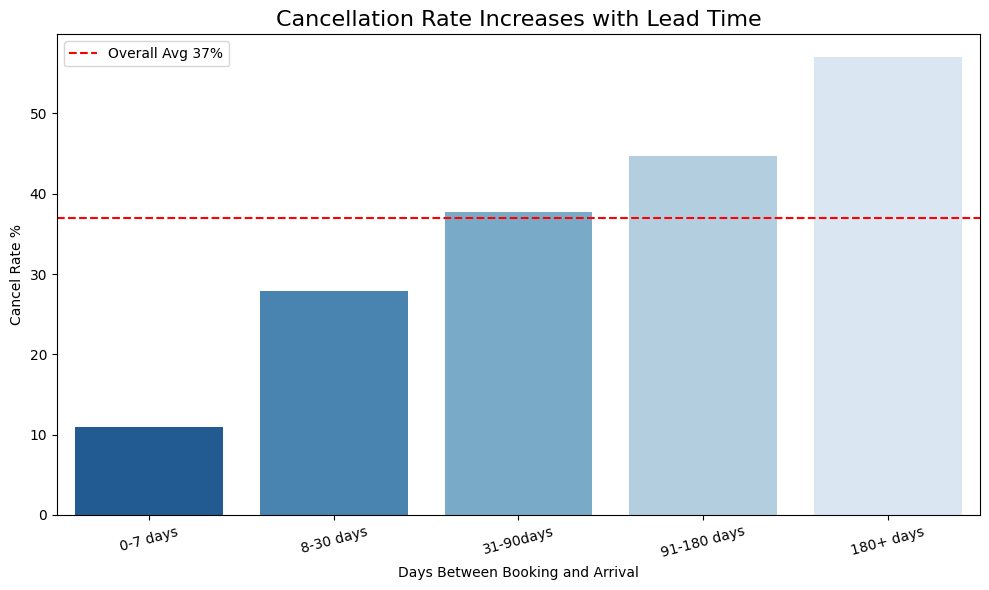

In [7]:
# Chart 
plt.figure(figsize=(10,6))
sns.barplot(data=leadtime_result, x='lead_time_bucket', y='cancel_rate_pct', 
            hue='lead_time_bucket', palette='Blues_r', legend=False)
plt.title('Cancellation Rate Increases with Lead Time', fontsize=16)
plt.xlabel('Days Between Booking and Arrival')
plt.ylabel('Cancel Rate %')
plt.xticks(rotation=15)
plt.axhline(y=37.04, color='red', linestyle='--', label='Overall Avg 37%')
plt.legend()
plt.tight_layout()
plt.show()

Key Finding 2: Longer Lead Time = Higher Risk
Bookings made 180+ days in advance have the highest cancel rate, often exceeding 50%
Bookings within 7 days have the lowest cancel rate, around 15-20%
The risk increases significantly after 30 days of lead time
Business Impact for Online Travel Agencies:
Customers who book far in advance are less committed. This is a major driver of revenue leakage.

Recommendation:
For bookings with 90+ days lead time, require a higher deposit or offer "non-refundable" discounts
Implement automated "excitement emails" at 60, 30, 7 days before arrival to keep customers engaged
Flag high lead-time bookings as "high-risk" in the system for proactive outreach

In [8]:
### Analysis 3: Top 10 Countries by Cancellation Rate

# the countries have above 500 booking
country_result = df.groupby('country').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum')
).reset_index()
country_result = country_result[country_result['total_bookings'] >= 500]
country_result['cancel_rate_pct'] = (country_result['canceled_bookings'] * 100 / country_result['total_bookings']).round(2)
country_result = country_result.sort_values('cancel_rate_pct', ascending=False).head(10)

print("Top 10 Countries with Highest Cancel Rate")
print(country_result)

Top 10 Countries with Highest Cancel Rate
    country  total_bookings  canceled_bookings  cancel_rate_pct
135     PRT           48590              27519            56.64
31      CHN             999                462            46.25
140     RUS             632                239            37.82
25      BRA            2224                830            37.32
81      ITA            3766               1333            35.40
124     NOR             607                181            29.82
139     ROU             500                134            26.80
51      ESP            8568               2177            25.41
80      ISR             669                169            25.26
29      CHE            1730                428            24.74


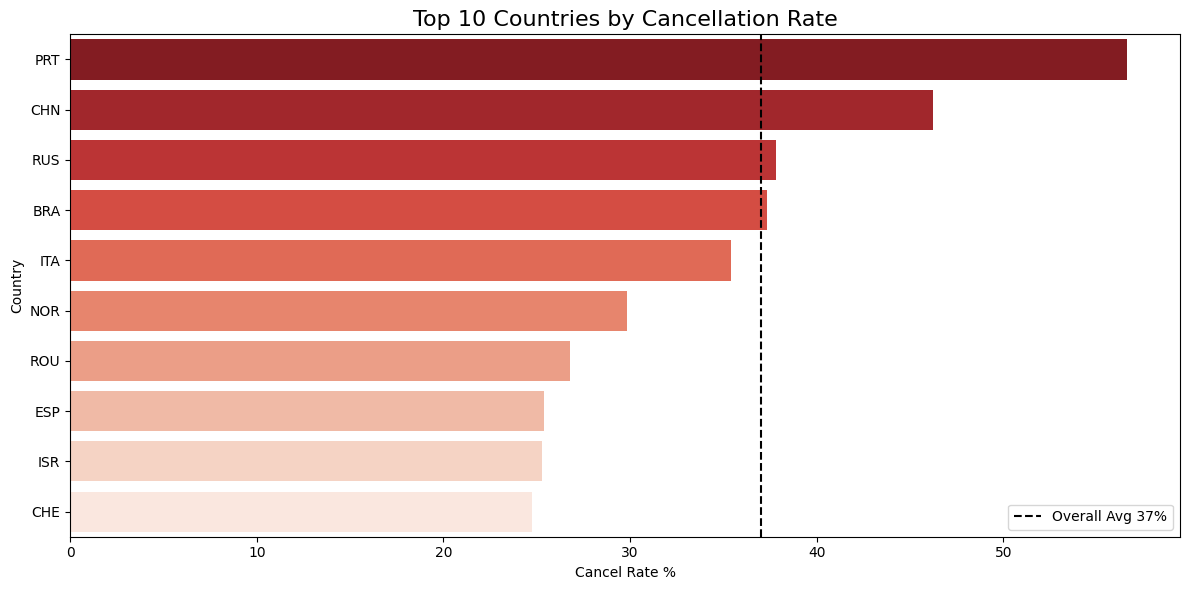

In [9]:
# Chart
plt.figure(figsize=(12,6))
sns.barplot(data=country_result, y='country', x='cancel_rate_pct',hue='country', palette='Reds_r', legend=False)
plt.title('Top 10 Countries by Cancellation Rate', fontsize=16)
plt.xlabel('Cancel Rate %')
plt.ylabel('Country')
plt.axvline(x=37.04, color='black', linestyle='--', label='Overall Avg 37%')
plt.legend()
plt.tight_layout()
plt.show()

Key Finding 3: Cancellation Rate Varies Significantly by Country
Certain countries show 45%+ cancellation rates, well above the 37% average
This identifies high-risk geographic markets for targeted policies
Business Impact for Online Travel Agencies:
A one-size-fits-all cancellation policy loses money. Country-specific policies are needed.

Recommendation:
Apply stricter deposit rules for bookings from high-cancel-rate countries
Localize marketing: promote "pay-now" deals in high-risk markets
Use this data to negotiate different commission terms with hotels in these regions